<a href="https://colab.research.google.com/github/kishor-cypto/projects/blob/main/Skin_Cancer_Classification_Using_MobileNetV2_on_ISIC_9_Class_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

import os
import json
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

In [12]:
base_dir = '/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration'

train_dir = os.path.join(base_dir, 'Train')
test_dir = os.path.join(base_dir, 'Test')

print("Classes:", os.listdir(train_dir))

Classes: ['basal cell carcinoma', 'squamous cell carcinoma', 'pigmented benign keratosis', 'seborrheic keratosis', 'vascular lesion', 'nevus', 'melanoma', 'actinic keratosis', 'dermatofibroma']


In [13]:
img_size = 224
batch_size = 32

epochs_initial = 10
epochs_finetune = 10

In [14]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)


test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [15]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)


test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 2239 images belonging to 9 classes.
Found 118 images belonging to 9 classes.


In [16]:
print("Training class distribution:", Counter(train_generator.classes))


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Training class distribution: Counter({np.int32(5): 462, np.int32(3): 438, np.int32(1): 376, np.int32(4): 357, np.int32(7): 181, np.int32(8): 139, np.int32(0): 114, np.int32(2): 95, np.int32(6): 77})
Class Weights: {0: np.float64(2.182261208576998), 1: np.float64(0.6616430260047281), 2: np.float64(2.6187134502923977), 3: np.float64(0.5679857940131913), 4: np.float64(0.6968565203859322), 5: np.float64(0.5384800384800384), 6: np.float64(3.230880230880231), 7: np.float64(1.3744628606507059), 8: np.float64(1.7897681854516387)}


In [17]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(img_size, img_size, 3)
)


base_model.trainable = False


x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.5)(x)


output = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)


model = Model(
    inputs=base_model.input,
    outputs=output
)


model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,619,977 (9.99 MB)

 Trainable params: 361,993 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [19]:
history = model.fit(
    train_generator,
    epochs=epochs_initial,
    validation_data=test_generator,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.1340 - loss: 2.5474 - val_accuracy: 0.1610 - val_loss: 2.1921
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.1621 - loss: 2.2680 - val_accuracy: 0.2458 - val_loss: 2.1105
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.1737 - loss: 2.1570 - val_accuracy: 0.2966 - val_loss: 2.0549
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.2108 - loss: 2.0812 - val_accuracy: 0.2966 - val_loss: 2.0180
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.2184 - loss: 2.0184 - val_accuracy: 0.2881 - val_loss: 1.9626
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.2300 - loss: 1.9930 - val_accuracy: 0.3644 - val_loss: 1.9112
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.2385 - loss: 1.9562 - val_accuracy: 0.3814 - val_loss: 1.8766
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.2479 - loss: 1.9043 - val_accuracy: 0.3898 - v

In [20]:
for layer in base_model.layers[-30:]:
    layer.trainable = True


model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history_finetune = model.fit(
    train_generator,
    epochs=epochs_finetune,
    validation_data=test_generator,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 195s 3s/step - accuracy: 0.2104 - loss: 2.0921 - val_accuracy: 0.3983 - val_loss: 1.7735
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 182s 3s/step - accuracy: 0.2296 - loss: 2.0258 - val_accuracy: 0.3898 - val_loss: 1.7605
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 226s 3s/step - accuracy: 0.2582 - loss: 1.9552 - val_accuracy: 0.3814 - val_loss: 1.7509
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 219s 3s/step - accuracy: 0.2537 - loss: 1.9054 - val_accuracy: 0.3983 - val_loss: 1.7359
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - accuracy: 0.2649 - loss: 1.8898 - val_accuracy: 0.3983 - val_loss: 1.7265
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.2742 - loss: 1.8491 - val_accuracy: 0.4068 - val_loss: 1.7151
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - accuracy: 0.2765 - loss: 1.8481 - val_accuracy: 0.4153 - val_loss: 1.7045
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 185s 3s/step - accuracy: 0.2961 - loss: 1.8216 - val_accuracy: 0.4068 - v

In [21]:
acc = history.history['accuracy'] + history_finetune.history['accuracy']

val_acc = history.history['val_accuracy'] + history_finetune.history['val_accuracy']


loss = history.history['loss'] + history_finetune.history['loss']

val_loss = history.history['val_loss'] + history_finetune.history['val_loss']


epochs_range = range(len(acc))

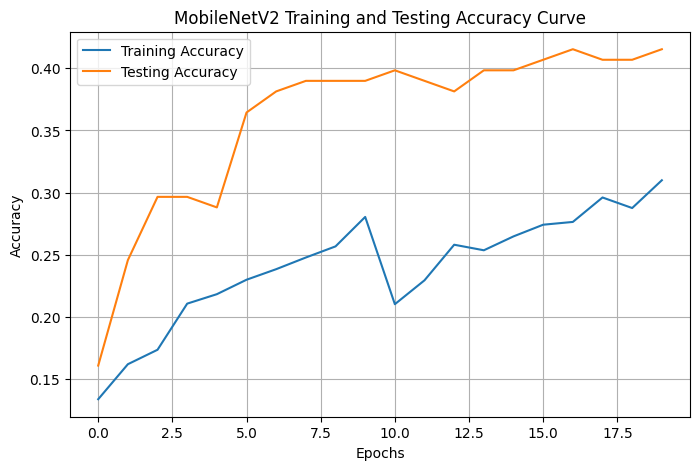

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs_range,
    acc,
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_acc,
    label="Testing Accuracy"
)


plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.title(
    "MobileNetV2 Training and Testing Accuracy Curve"
)

plt.legend()

plt.grid()

plt.show()

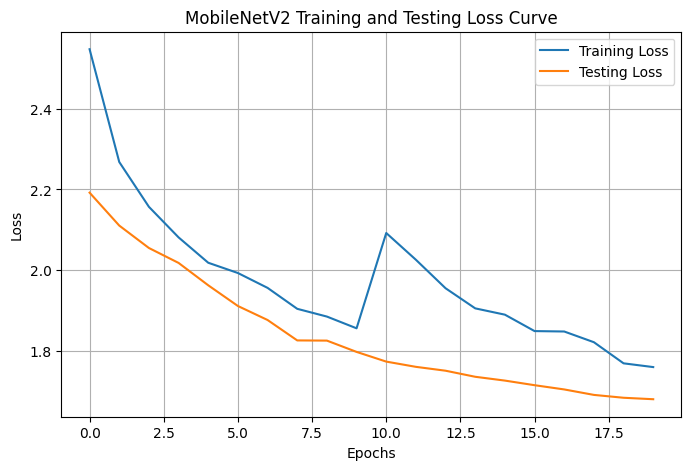

In [23]:
plt.figure(figsize=(8,5))


plt.plot(
    epochs_range,
    loss,
    label="Training Loss"
)


plt.plot(
    epochs_range,
    val_loss,
    label="Testing Loss"
)


plt.xlabel("Epochs")

plt.ylabel("Loss")


plt.title(
    "MobileNetV2 Training and Testing Loss Curve"
)


plt.legend()

plt.grid()

plt.show()

In [24]:
test_loss, test_accuracy = model.evaluate(test_generator)


print("Test Loss =", test_loss)

print("Test Accuracy =", test_accuracy*100,"%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.4153 - loss: 1.6803
Test Loss = 1.6803126335144043
Test Accuracy = 41.525423526763916 %


In [25]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize
import seaborn as sns

In [27]:
y_pred_prob = model.predict(test_generator)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

y_true = test_generator.classes


class_names = list(test_generator.class_indices.keys())

4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step


In [28]:
f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)


print("Weighted F1 Score:", f1)

Weighted F1 Score: 0.3934851009947301


In [29]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                            precision    recall  f1-score   support

         actinic keratosis       0.62      0.31      0.42        16
      basal cell carcinoma       0.36      0.56      0.44        16
            dermatofibroma       0.50      0.38      0.43        16
                  melanoma       0.43      0.19      0.26        16
                     nevus       0.50      0.88      0.64        16
pigmented benign keratosis       0.33      0.25      0.29        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.28      0.31      0.29        16
           vascular lesion       0.60      1.00      0.75         3

                  accuracy                           0.42       118
                 macro avg       0.40      0.43      0.39       118
              weighted avg       0.43      0.42      0.39       118



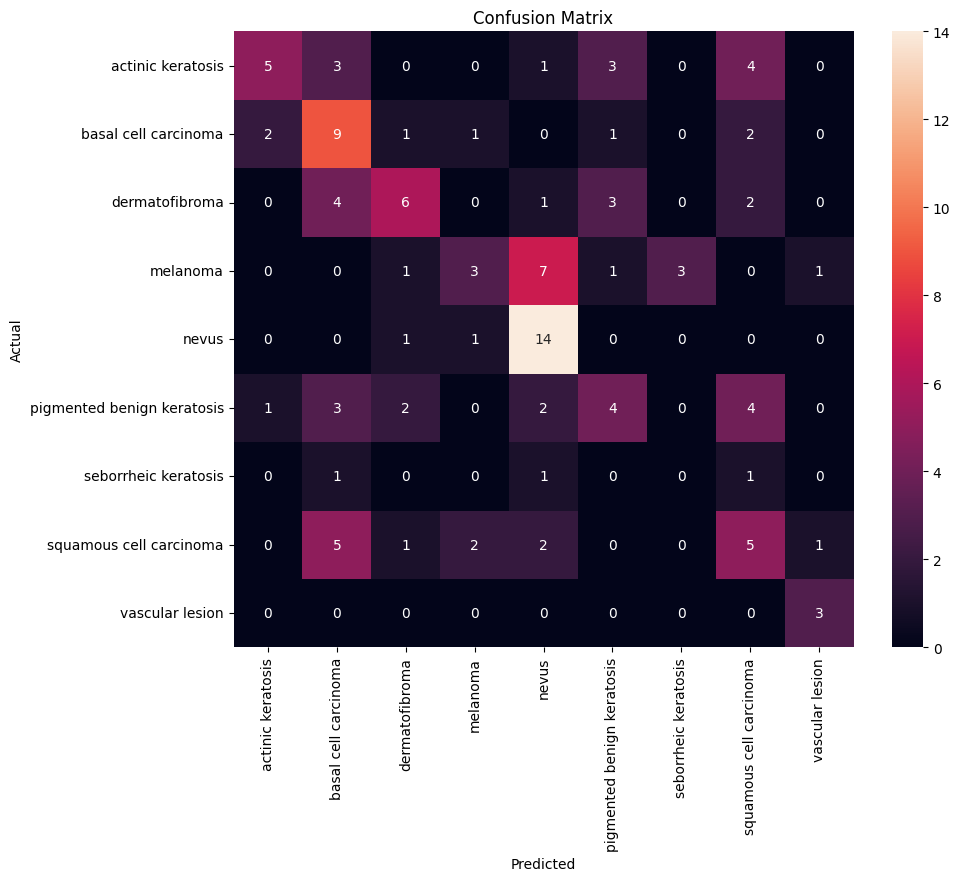

In [30]:
cm = confusion_matrix(
    y_true,
    y_pred
)


plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)


plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

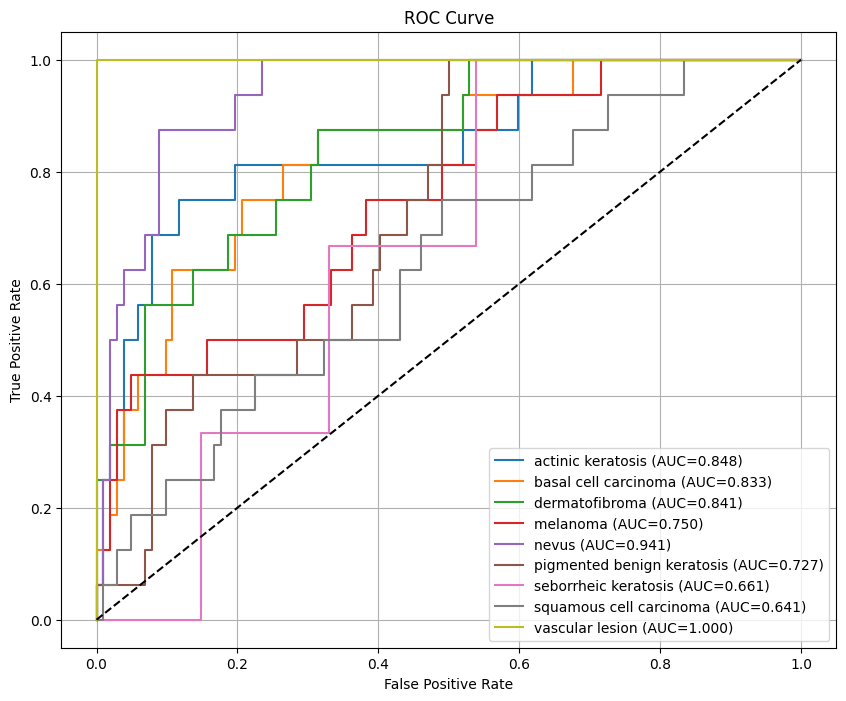

In [31]:
y_true_binary = label_binarize(
    y_true,
    classes=np.arange(len(class_names))
)


plt.figure(figsize=(10,8))


for i in range(len(class_names)):

    fpr, tpr, _ = roc_curve(
        y_true_binary[:,i],
        y_pred_prob[:,i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )


    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC={roc_auc:.3f})"
    )


plt.plot(
    [0,1],
    [0,1],
    'k--'
)


plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

In [32]:
roc_auc = roc_auc_score(
    y_true_binary,
    y_pred_prob,
    multi_class='ovr'
)


print(
    "Overall ROC AUC Score:",
    roc_auc
)

Overall ROC AUC Score: 0.8046391020176187
